In [ ]:
# import library
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

In [2]:
# loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [ ]:
# search for job that based in Indonesia
df_indo = df[df['job_country'] == 'Indonesia'].copy()
df_indo

In [ ]:
# transform month from numeric into string 
df_indo['job_posted_month'] = df_indo['job_posted_date'].dt.strftime('%B')
df_indo.job_posted_month.head(6)

643        July
1213      April
1244     August
1858        May
2048        May
2489    October
Name: job_posted_month, dtype: object

In [70]:
# create pivot
df_indo_pivot = df_indo.pivot_table(index="job_posted_month", columns='job_title_short', aggfunc='size')

In [71]:
# Sorting month

# Reset index (sekali aja)
df_indo_pivot.reset_index(inplace=True)

In [72]:
# Take kolom job posted month, terus di format jadi ke angka
df_indo_pivot['month_no'] = pd.to_datetime(df_indo_pivot['job_posted_month'], format='%B').dt.month

In [ ]:
# Sort month dari jan ke dec 
df_indo_pivot.sort_values('month_no', inplace=True)

# ngeset kolom job_posted_month jadi index 
# kalau udah di set, gabisa di run lagi, kecuali udah di reset lagi indexnya
df_indo_pivot.set_index('job_posted_month',inplace=True)

# drop kolom month_no
df_indo_pivot.drop(columns='month_no',inplace=True)

In [80]:
df_indo_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,14,9,35,117,80,8,5,10,19,14
February,9,2,25,78,44,5,4,12,5,18
March,6,5,21,90,36,2,1,13,5,14
April,5,3,20,46,28,2,1,9,8,14
May,11,9,25,79,39,3,2,8,9,4
June,11,4,22,66,32,4,1,8,9,8
July,11,3,25,58,46,9,4,8,3,20
August,12,5,32,78,46,1,3,5,5,15
September,4,7,34,83,50,6,5,10,8,9


<Axes: xlabel='job_posted_month'>

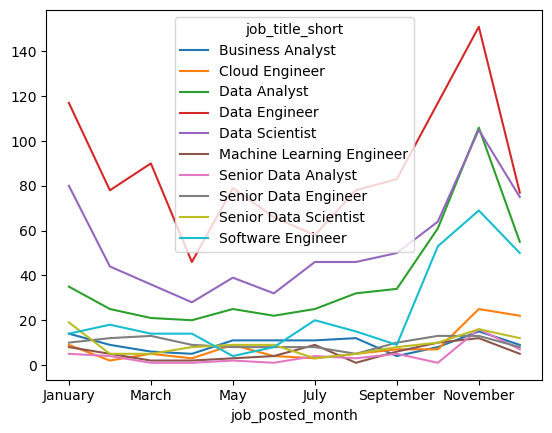

In [ ]:
# create line graph
df_indo_pivot.plot(kind='line')

# bisa dilihat terlalu banyak jenis job nya, akan diubah jadi top 5 aja

In [93]:
# Top 5 jobs 
top_5 = df_indo['job_title_short'].value_counts().head(5)

# take index and put into list 
top_5 = top_5.index.tolist()

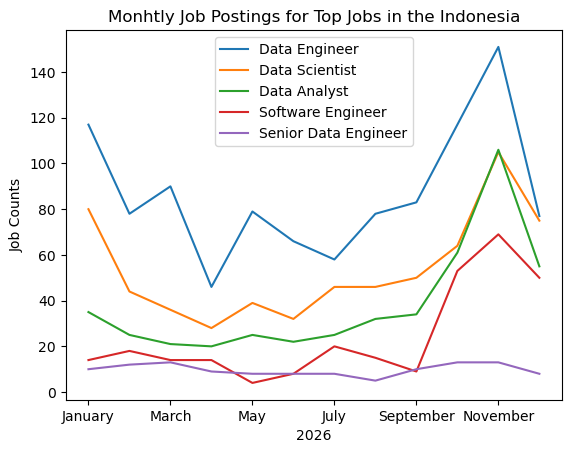

In [99]:
# top 5 graph 
df_indo_pivot[top_5].plot(kind='line')
plt.title('Monhtly Job Postings for Top Jobs in the Indonesia')
plt.xlabel('2026')
plt.ylabel('Job Counts')
plt.legend()
plt.show()
